## 1. Business understanding: The first phase is to understand the business problem that needs to be solved. What is the goal of the analysis? What are the requirements and constraints? What is the expected outcome?

What we seek to establish and understand is the relationship between the well-being of children and young people and the factors that influence it. The goal is to identify the factors that have the greatest impact on the well-being of children and young people, and to use this information to improve the well-being of children and young people in the future. The expected outcome is a model that can predict the well-being of children and young people based on the factors that influence it.

The requirements and constraints are as follows:
- The data must be collected from reliable sources.
- The data must be cleaned and preprocessed before it can be used for analysis.
- The model must be trained and validated using machine learning methods.
- The model must be evaluated to determine how well it performs.
- Questions must be set before the analysis begins.
- Model follows the crisp dm model.

### Questions:
- What factors have the greatest impact on the well-being of children and young people?
- How can we use this information to improve the well-being of children and young people in the future?
- What is the relationship between the well-being of children and young people and the factors that influence it?
- What is the expected outcome of the analysis?
- What is the effect of substance abuse on the willingness to attend school, depression, and general well-being?
- What is the impact of school bullying on general health and school attendance?
- What is the effect of family relationships on general well-being and school attendance?
- General well-being and trends:
    - How has the well-being of children and young people developed in Helsinki over the years?
    - Which areas of well-being (health, education, social well-being) have improved or deteriorated?
    - Are there areas with better or worse well-being than others?
- Regional differences and background factors:
    - Are there regional differences in the well-being of children and young people between different districts of Helsinki?
    - How do factors such as family income level or parents' education level affect well-being?
    - Are there significant well-being differences between children of immigrant backgrounds and native Finnish children?
- Education and learning:
    - How are school performance or school absences related to well-being?
    - Is there a noticeable connection between family socioeconomic background and learning outcomes?
    - Does school performance predict later well-being problems?
- Mental health and social well-being:
    - What factors predict mental health problems in young people?
    - Is school bullying associated with other well-being problems?
    - What factors predict the risk of social exclusion?
- Physical activity, nutrition, and health:
    - How do exercise habits affect well-being?
    - Is there a connection between the amount of sleep and mental health problems?
    - Does an unhealthy diet predict other well-being problems?
- Predictive models and recommendations:
    - Can a model be built to predict children at risk of well-being issues?
    - What measures could be recommended to improve well-being?
    - Can early signs of problems be identified to target preventive measures effectively?

## 2. Data understanding: The second phase is to collect and explore the data. What data is available? What are the characteristics of the data (variable types, value distributions etc.)? Are there any quality issues with the data (missing values, outliers, nonsensical values)?

In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from mlxtend.frequent_patterns import apriori, association_rules

# Load the data
TE05 = pd.read_csv('TE05_Mielen_hyvinvointi_oppiasteen_sukupuolen_mukaan_2013-.csv', encoding='iso-8859-1')
mieli = pd.read_csv('009g_Mielen_hyvinvointi_oppiasteen_sukupuolen_mukaan_2013-.csv', encoding='iso-8859-1')
population = pd.read_csv('lasten_nuorten_maara_alue_ikasuos_sukupuoli_vuosi_tiedot.csv', encoding='iso-8859-1')
paihde = pd.read_csv('paihdedata_oppiasteen_sukupuolen_mukaan.csv', encoding='iso-8859-1')
kiusaaminen = pd.read_csv('Koulukiusaaminen_oppiasteen_sukupuolen_mukaan_2006-.csv', encoding='iso-8859-1')
aktiivi = pd.read_csv('Aktiiviosallistuneet_20-54_vuotiaat_perhetilanteen_mukaan_2013.csv', encoding='iso-8859-1')

In [49]:
# Convert all columns after the fourth column to numerical
population.iloc[:, 4:] = population.iloc[:, 4:].apply(pd.to_numeric, errors='coerce')

# Display the DataFrame
print(population.head())

           Alue Äidinkieli            Ikä Sukupuoli  2000 Väestö 31.12.  \
0  091 Helsinki   Yhteensä   0-6-vuotiaat  Yhteensä               40306   
1  091 Helsinki   Yhteensä   0-6-vuotiaat    Miehet               20503   
2  091 Helsinki   Yhteensä   0-6-vuotiaat    Naiset               19803   
3  091 Helsinki   Yhteensä  7-12-vuotiaat  Yhteensä               33746   
4  091 Helsinki   Yhteensä  7-12-vuotiaat    Miehet               17203   

   2001 Väestö 31.12.  2002 Väestö 31.12.  2003 Väestö 31.12.  \
0               39224               38311               37784   
1               20025               19594               19214   
2               19199               18717               18570   
3               34062               33992               33457   
4               17365               17261               17133   

   2004 Väestö 31.12.  2005 Väestö 31.12.  ...  2016 Väestö 31.12.  \
0               37199               36884  ...               45807   
1               18

In [50]:

# Display the first few rows of the dataframe
print("First few rows of the dataframe:")
population.head()

First few rows of the dataframe:


,Alue,Äidinkieli,Ikä,Sukupuoli,2000 Väestö 31.12.,2001 Väestö 31.12.,2002 Väestö 31.12.,2003 Väestö 31.12.,2004 Väestö 31.12.,2005 Väestö 31.12.,...,2016 Väestö 31.12.,2017 Väestö 31.12.,2018 Väestö 31.12.,2019 Väestö 31.12.,2020 Väestö 31.12.,2021 Väestö 31.12.,2022 Väestö 31.12.,2023 Väestö 31.12.,2006 Väestö 31.12.,2007 Väestö 31.12.
0,091 Helsinki,Yhteensä,0-6-vuotiaat,Yhteensä,40306,39224,38311,37784,37199,36884,...,45807,46033,45799,45281,44722,44030,43187,42912,0,0
1,091 Helsinki,Yhteensä,0-6-vuotiaat,Miehet,20503,20025,19594,19214,18996,18675,...,23623,23682,23466,23140,22825,22469,22085,22027,18715,0
2,091 Helsinki,Yhteensä,0-6-vuotiaat,Naiset,19803,19199,18717,18570,18203,18209,...,22184,22351,22333,22141,21897,21561,21102,20885,18139,18031
3,091 Helsinki,Yhteensä,7-12-vuotiaat,Yhteensä,33746,34062,33992,33457,32747,31745,...,33730,35149,36113,37098,37967,38439,38998,39357,0,0
4,091 Helsinki,Yhteensä,7-12-vuotiaat,Miehet,17203,17365,17261,17133,16682,16236,...,17193,17915,18459,19007,19483,19687,20024,20173,15700,0


In [51]:

# Check the data types of each column
print("\nData types of each column:")
population.dtypes


Data types of each column:


Alue                  object
Äidinkieli            object
Ikä                   object
Sukupuoli             object
2000 Väestö 31.12.     int64
2001 Väestö 31.12.     int64
2002 Väestö 31.12.     int64
2003 Väestö 31.12.     int64
2004 Väestö 31.12.     int64
2005 Väestö 31.12.     int64
2008 Väestö 31.12.     int64
2009 Väestö 31.12.     int64
2010 Väestö 31.12.     int64
2011 Väestö 31.12.     int64
2012 Väestö 31.12.     int64
2013 Väestö 31.12.     int64
2014 Väestö 31.12.     int64
2015 Väestö 31.12.     int64
2016 Väestö 31.12.     int64
2017 Väestö 31.12.     int64
2018 Väestö 31.12.     int64
2019 Väestö 31.12.     int64
2020 Väestö 31.12.     int64
2021 Väestö 31.12.     int64
2022 Väestö 31.12.     int64
2023 Väestö 31.12.     int64
2006 Väestö 31.12.     int64
2007 Väestö 31.12.     int64
dtype: object

In [52]:
# Get summary statistics
print("\nSummary statistics:")
population.describe(include='all')


Summary statistics:


,Alue,Äidinkieli,Ikä,Sukupuoli,2000 Väestö 31.12.,2001 Väestö 31.12.,2002 Väestö 31.12.,2003 Väestö 31.12.,2004 Väestö 31.12.,2005 Väestö 31.12.,...,2016 Väestö 31.12.,2017 Väestö 31.12.,2018 Väestö 31.12.,2019 Väestö 31.12.,2020 Väestö 31.12.,2021 Väestö 31.12.,2022 Väestö 31.12.,2023 Väestö 31.12.,2006 Väestö 31.12.,2007 Väestö 31.12.
count,96,96,96,96,96.000000,96.000000,96.000000,96.000000,96.000000,96.000000,...,96.000000,96.000000,96.000000,96.000000,96.000000,96.000000,96.000000,96.000000,96.000000,96.000000
unique,1,4,8,3,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,091 Helsinki,Yhteensä,0-6-vuotiaat,Yhteensä,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,96,24,12,32,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,12686.875000,12749.708333,12724.750000,12694.333333,12629.625000,12591.875000,...,13290.083333,13421.958333,13412.708333,13402.208333,13380.333333,13374.541667,13431.916667,13626.083333,9449.312500,7899.583333
std,NaN,NaN,NaN,NaN,18093.199005,18049.790036,17952.755007,17828.690912,17663.582946,17487.336244,...,14905.671405,14967.273356,14829.039654,14715.789348,14564.396017,14344.573919,14191.392774,14183.778180,13819.892948,13031.579059
min,NaN,NaN,NaN,NaN,151.000000,197.000000,158.000000,155.000000,160.000000,172.000000,...,455.000000,455.000000,469.000000,474.000000,487.000000,508.000000,523.000000,549.000000,0.000000,0.000000
25%,NaN,NaN,NaN,NaN,1217.250000,1253.250000,1326.500000,1395.000000,1407.500000,1426.750000,...,2392.500000,2411.750000,2471.500000,2568.250000,2647.250000,2776.500000,2970.000000,2962.500000,975.250000,521.250000
50%,NaN,NaN,NaN,NaN,3542.000000,3838.500000,4013.000000,4246.000000,4390.500000,4771.500000,...,6670.500000,7145.500000,7411.500000,7588.000000,7835.000000,8131.000000,8613.500000,9115.500000,2911.500000,2377.500000
75%,NaN,NaN,NaN,NaN,17780.000000,17602.500000,17400.500000,17213.250000,16879.750000,17008.500000,...,20690.750000,20094.000000,19226.250000,19071.250000,18955.000000,18985.750000,19082.000000,19201.000000,14524.250000,8363.750000


In [53]:

# Check for missing values
print("\nMissing values in each column:")
population.isnull().sum()


Missing values in each column:


Alue                  0
Äidinkieli            0
Ikä                   0
Sukupuoli             0
2000 Väestö 31.12.    0
2001 Väestö 31.12.    0
2002 Väestö 31.12.    0
2003 Väestö 31.12.    0
2004 Väestö 31.12.    0
2005 Väestö 31.12.    0
2008 Väestö 31.12.    0
2009 Väestö 31.12.    0
2010 Väestö 31.12.    0
2011 Väestö 31.12.    0
2012 Väestö 31.12.    0
2013 Väestö 31.12.    0
2014 Väestö 31.12.    0
2015 Väestö 31.12.    0
2016 Väestö 31.12.    0
2017 Väestö 31.12.    0
2018 Väestö 31.12.    0
2019 Väestö 31.12.    0
2020 Väestö 31.12.    0
2021 Väestö 31.12.    0
2022 Väestö 31.12.    0
2023 Väestö 31.12.    0
2006 Väestö 31.12.    0
2007 Väestö 31.12.    0
dtype: int64

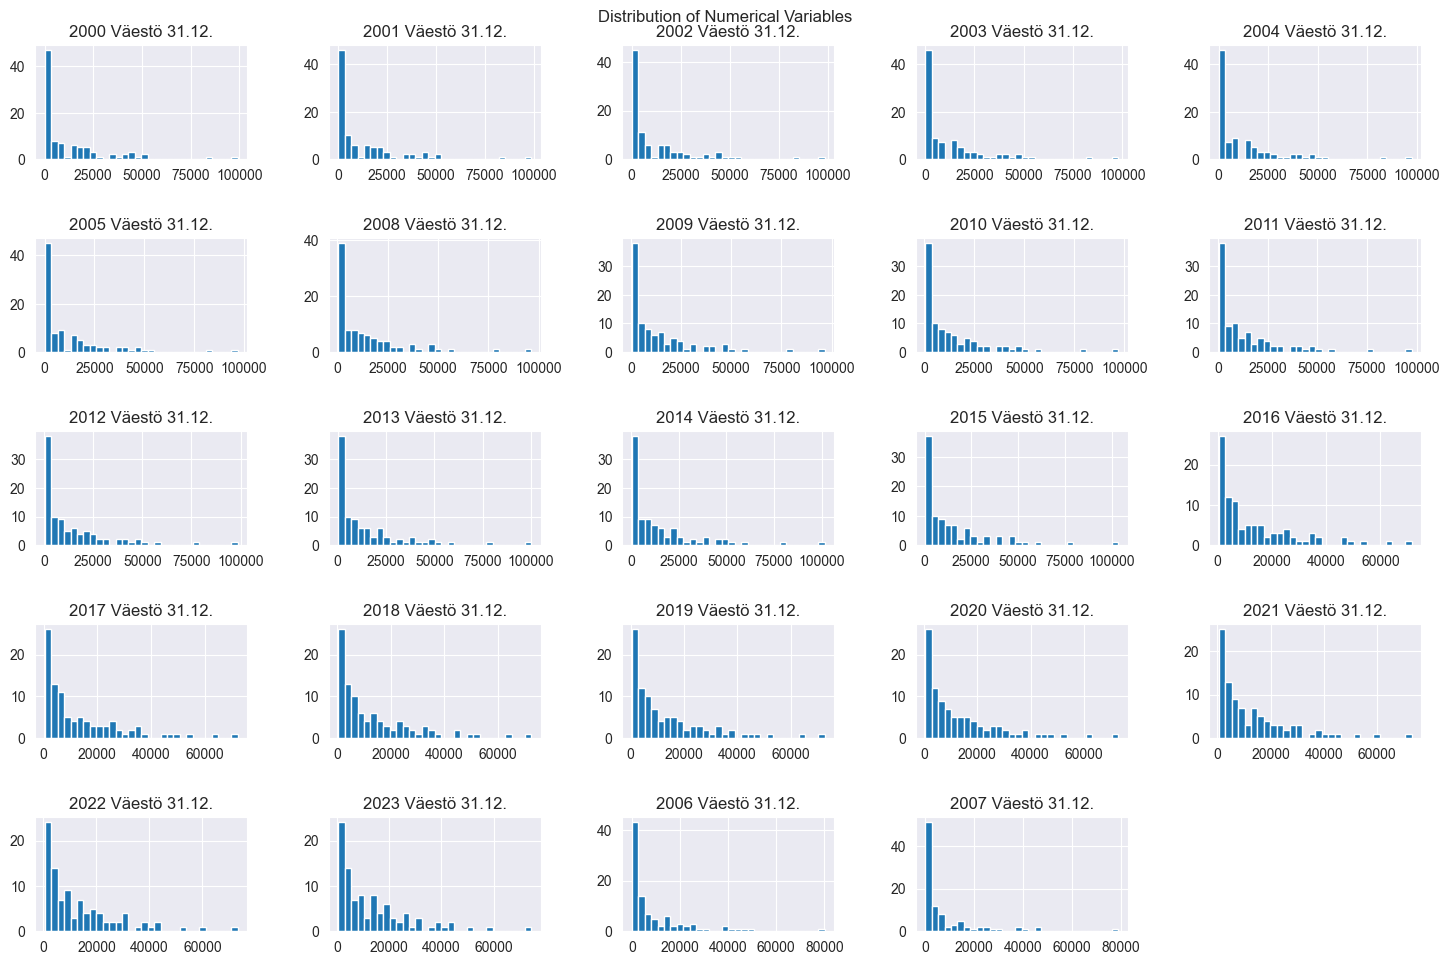

In [54]:

# Visualize the distribution of numerical variables
population.select_dtypes(include=['number']).hist(bins=30, figsize=(15, 10))
plt.tight_layout(pad=2.5)
plt.suptitle('Distribution of Numerical Variables')
plt.show()

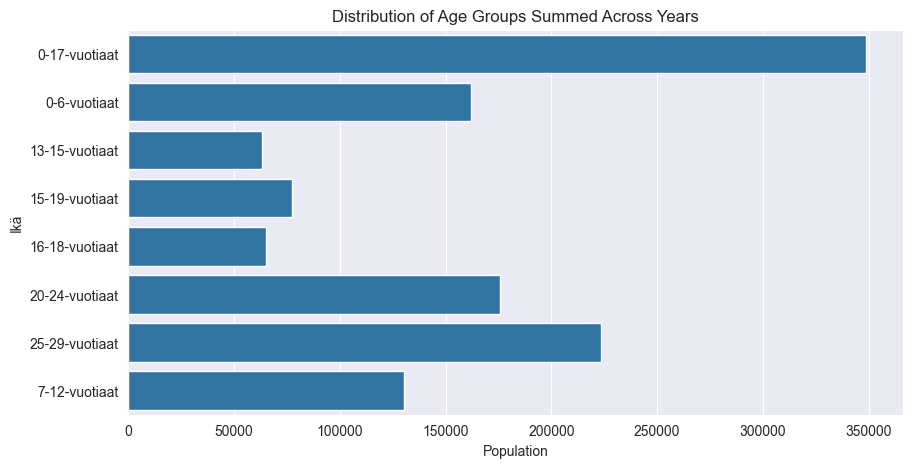

In [55]:
# Visualize the distribution of age groups

age_group_columns = [col for col in population.columns if 'Väestö' in col]
df_aggregated = population.groupby('Ikä')[age_group_columns].sum().reset_index()

# Melt the DataFrame to long format for easier plotting
df_melted = df_aggregated.melt(id_vars='Ikä', var_name='Year', value_name='Population')

# Convert 'Population' to numeric to ensure correct plotting
df_melted['Population'] = pd.to_numeric(df_melted['Population'], errors='coerce')

# Visualize the distribution of age groups

plt.figure(figsize=(10, 5))
sns.barplot(x='Population', y='Ikä', data=df_melted, errorbar=None)
plt.title('Distribution of Age Groups Summed Across Years')
plt.show()


## 3. Data preparation: The third phase is to preprocess the data. This includes cleaning the data, transforming the data, and selecting the relevant features. These steps should be documented in such detail that they can be reproduced later.

## 4. Modeling: The fourth phase is to choose a machine learning method and train the model. This phase also includes the validation of the model. Documentation needs include: which method was used, which parameters were used, what was the performance of the model?

## 5. Evaluation: The fifth phase is to evaluate the model. How well does the model perform? Does it meet the business requirements?

## 6. Deployment: The final phase is to deploy the model. How will the model be used in practice? How will the results be communicated? This phase may involve creating a recommendation of how to use the model in practice, or what to do next.